# Test RMTS vs. Kriging on RANS data

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from scipy.interpolate import make_smoothing_spline
from smt.surrogate_models import RMTB, RMTC, KRG

plt.rcParams["figure.figsize"] = (7, 4.5)

# Font sizes scaled up from matplotlib's defaults (10pt @ 100dpi) because the
# comparison plots below are rendered much wider (up to figsize=(18,5) for
# triplets, 6*n_models wide for grid comparisons) -- at default font sizes,
# labels/legends/titles end up a small fraction of the image and look tiny
# once the wide image is scaled down to fit a notebook/markdown viewer.
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 18,
})

In [2]:
DEG2RAD = np.pi / 180.0
RAD2DEG = 180.0 / np.pi

## Load and prepare the data

In [3]:
rans_df = pd.read_csv("../data/rans_data.csv")
raw_data = rans_df.to_numpy()
colnames = rans_df.columns.tolist()

In [4]:
rans_df

,alpha,mach,cd,cl,cmx,cmy,cmz
0,2.00,0.45,0.015368,0.367424,0.559228,-0.125804,-0.012487
1,3.50,0.45,0.019851,0.490447,0.757460,-0.161526,0.008987
2,5.00,0.45,0.025710,0.610919,0.949795,-0.195462,0.040909
3,6.50,0.45,0.033042,0.726612,1.131139,-0.225589,0.081854
4,8.00,0.45,0.043190,0.824725,1.271487,-0.239704,0.121766
5,0.00,0.58,0.011362,0.204876,0.295028,-0.078821,-0.022801
6,1.50,0.58,0.014260,0.337562,0.511413,-0.118942,-0.015882
7,3.00,0.58,0.018664,0.468745,0.724040,-0.157767,0.003100
8,4.50,0.58,0.024620,0.597664,0.931171,-0.194416,0.033575
9,6.00,0.58,0.032807,0.714225,1.111708,-0.220587,0.071517


## Utility functions

In [5]:
def get_rans_crm_wing():
    # data structure:
    # alpha, mach, cd, cl, cmx, cmy, cmz

    deg2rad = np.pi / 180.0

    xt = np.array(raw_data[:, 0:2])
    yt = np.array(raw_data[:, 2:4])
    xlimits = np.array([[-3.0, 10.0], [0.4, 0.90]])

    xt[:, 0] *= deg2rad
    xlimits[0, :] *= deg2rad

    return xt, yt, xlimits

In [6]:
# ---------------------------------------------------------------------------
# Prediction (no matplotlib here)
# ---------------------------------------------------------------------------

def _predict(model, alpha_deg, mach):
    """Evaluate a single-output model at broadcastable alpha (deg) / Mach arrays."""
    alpha_deg, mach = np.broadcast_arrays(np.asarray(alpha_deg, float),
                                          np.asarray(mach, float))
    x = np.column_stack([alpha_deg.ravel() * DEG2RAD, mach.ravel()])
    y = model.predict_values(x)
    if y.ndim == 2 and y.shape[1] != 1:
        raise ValueError(f"Expected a single-output model, got {y.shape[1]} outputs")
    return y.ravel().reshape(alpha_deg.shape)


def predict_alpha_sweeps(model, mach_numbers, alpha_deg):
    """Return {mach: y(alpha)} for each Mach number."""
    return {m: _predict(model, alpha_deg, m) for m in mach_numbers}


def predict_mach_sweeps(model, alphas_deg, mach):
    """Return {alpha_deg: y(mach)} for each angle of attack."""
    return {a: _predict(model, a, mach) for a in alphas_deg}


def predict_grid(model, alpha_deg, mach):
    """Return (ALPHA_deg, MACH, Y) meshgrids, shape (len(alpha), len(mach))."""
    A, M = np.meshgrid(alpha_deg, mach, indexing="ij")
    return A, M, _predict(model, A, M)

### A 2-D surrogate from `scipy.interpolate.make_smoothing_spline`

`make_smoothing_spline` is strictly **1-D** -- it has no native notion of a
second input like Mach number, so it can't be dropped in as a `(alpha, mach)`
model the way `RMTB`/`KRG` are. The training data is naturally organized as 7
discrete Mach slices (5 alpha points each, confirmed in `rans_df` above), so
`LoftedSmoothingSpline` below builds a genuine (if compound) 2-D surrogate by
**lofting** 1-D splines across Mach:

1. one `make_smoothing_spline(alpha, y)` per training Mach slice (the "profile"
   direction), and
2. a second `make_smoothing_spline(mach, y)` across those slices, evaluated at
   whatever alpha was actually queried (the "lofting" direction).

This is the same construction `LoftedSplineVolume` used in
`../Test Meta Models.ipynb`, built directly from `scipy` here instead of the
SplineCloud client, specifically so it exposes the same `predict_values(X)`
interface as `RMTB`/`KRG` and plugs into the existing comparison code
unmodified. `lam=None` (GCV) by default, matching "no specific hyperparameters,
tune later" for the other models.

In [7]:
class LoftedSmoothingSpline:
    """A 2-D (alpha, mach) surrogate built by lofting 1-D
    scipy.interpolate.make_smoothing_spline fits across Mach. See the markdown
    cell above for the construction. Exposes predict_values(X) with the same
    X=[alpha_rad, mach] convention _predict uses, so it works with
    predict_alpha_sweeps / predict_mach_sweeps / predict_grid unchanged.
    """

    def __init__(self, xt, y, lam=None):
        self.lam = lam
        y = np.asarray(y, dtype=float).ravel()
        self.mach_vals = np.unique(xt[:, 1])
        self.alpha_splines = {}
        for m in self.mach_vals:
            mask = np.isclose(xt[:, 1], m)
            a_deg = xt[mask, 0] * RAD2DEG
            order = np.argsort(a_deg)
            self.alpha_splines[m] = make_smoothing_spline(a_deg[order], y[mask][order], lam=lam)

    def predict_values(self, X):
        X = np.asarray(X, dtype=float)
        alpha_deg = X[:, 0] * RAD2DEG
        mach = X[:, 1]
        out = np.empty(len(X))

        # Evaluate every per-Mach-slice spline at only the unique queried
        # alphas (predict_grid repeats each alpha across many Mach values),
        # then loft across Mach once per unique alpha -- avoids refitting a
        # mach-direction spline per query point.
        unique_alphas, inv = np.unique(alpha_deg, return_inverse=True)
        slice_vals = np.array(
            [[spl(a) for a in unique_alphas] for spl in self.alpha_splines.values()]
        )

        for j in range(len(unique_alphas)):
            mach_spline = make_smoothing_spline(self.mach_vals, slice_vals[:, j], lam=self.lam)
            mask = inv == j
            out[mask] = mach_spline(mach[mask])

        return out.reshape(-1, 1)

In [8]:
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_alpha_sweeps(ax, alpha_deg, sweeps, xt=None, yt=None, label="y"):
    for (mach, y), color in zip(sweeps.items(), plt.cm.tab10.colors):
        ax.plot(alpha_deg, y, color=color, label=f"M={mach}")
        if xt is not None:
            mask = np.isclose(xt[:, 1], mach)
            ax.plot(xt[mask, 0] * RAD2DEG, yt[mask], "o", color=color)
    
    ax.set(xlabel="alpha (deg)", ylabel=label)
    ax.legend()


def plot_mach_sweeps(ax, mach, sweeps, xt=None, yt=None, label="y", alpha_tol=1e-2):
    """Training points are shown where |alpha_data - alpha_sweep| <= alpha_tol (deg)."""
    for (alpha, y), color in zip(sweeps.items(), plt.cm.tab10.colors):
        ax.plot(mach, y, color=color, label=f"alpha={alpha}°")
        if xt is not None:
            mask = np.abs(xt[:, 0] * RAD2DEG - alpha) <= alpha_tol
            ax.plot(xt[mask, 1], yt[mask], "o", color=color)
    
    ax.set(xlabel="Mach number", ylabel=label)
    ax.legend()


def plot_contour(ax, A, M, Y, xt=None, label="y", levels=20):
    pcm = ax.pcolormesh(M, A, Y, cmap="rainbow", shading="auto")
    ax.contour(M, A, Y, levels, colors="k", linewidths=0.5)
    if xt is not None:
        ax.plot(xt[:, 1], xt[:, 0] * RAD2DEG, "ko", markersize=3)
    ax.figure.colorbar(pcm, ax=ax)
    ax.set(xlabel="Mach number", ylabel="alpha (deg)", title=label)


In [9]:
def plot_alpha_sweeps_compare(ax, alpha_deg, sweeps_by_model, xt=None, yt=None, label="y"):
    """sweeps_by_model: {model_label: {mach: y(alpha)}}, i.e. predict_alpha_sweeps
    run once per model. Color = Mach condition (as in plot_alpha_sweeps),
    linestyle = model."""
    linestyles = ["-", "--", ":", "-."]
    machs = list(next(iter(sweeps_by_model.values())).keys())
    colors = dict(zip(machs, plt.cm.tab10.colors))

    for mind, (model_label, sweeps) in enumerate(sweeps_by_model.items()):
        ls = linestyles[mind % len(linestyles)]
        for mach, y in sweeps.items():
            ax.plot(alpha_deg, y, ls, color=colors[mach])

    if xt is not None:
        for mach, color in colors.items():
            mask = np.isclose(xt[:, 1], mach)
            ax.plot(xt[mask, 0] * RAD2DEG, yt[mask], "o", color=color)

    ax.set(xlabel="alpha (deg)", ylabel=label)
    cond_handles = [Line2D([0], [0], color=c, marker="o", label=f"M={m}") for m, c in colors.items()]
    model_handles = [Line2D([0], [0], color="0.2", linestyle=linestyles[i % len(linestyles)], label=lbl)
                      for i, lbl in enumerate(sweeps_by_model.keys())]
    leg1 = ax.legend(handles=cond_handles, loc="upper left", title="condition")
    ax.add_artist(leg1)
    ax.legend(handles=model_handles, loc="upper right", title="model")


def plot_mach_sweeps_compare(ax, mach, sweeps_by_model, xt=None, yt=None, label="y", alpha_tol=1e-2):
    """sweeps_by_model: {model_label: {alpha_deg: y(mach)}}. Color = alpha
    condition, linestyle = model."""
    linestyles = ["-", "--", ":", "-."]
    alphas = list(next(iter(sweeps_by_model.values())).keys())
    colors = dict(zip(alphas, plt.cm.tab10.colors))

    for mind, (model_label, sweeps) in enumerate(sweeps_by_model.items()):
        ls = linestyles[mind % len(linestyles)]
        for alpha, y in sweeps.items():
            ax.plot(mach, y, ls, color=colors[alpha])

    if xt is not None:
        for alpha, color in colors.items():
            mask = np.abs(xt[:, 0] * RAD2DEG - alpha) <= alpha_tol
            ax.plot(xt[mask, 1], yt[mask], "o", color=color)

    ax.set(xlabel="Mach number", ylabel=label)
    cond_handles = [Line2D([0], [0], color=c, marker="o", label=f"alpha={a}°") for a, c in colors.items()]
    model_handles = [Line2D([0], [0], color="0.2", linestyle=linestyles[i % len(linestyles)], label=lbl)
                      for i, lbl in enumerate(sweeps_by_model.keys())]
    leg1 = ax.legend(handles=cond_handles, loc="upper left", title="condition")
    ax.add_artist(leg1)
    ax.legend(handles=model_handles, loc="upper right", title="model")


def rmse_table(xt, y_true, models):
    """models: {label: fitted single-output model}. Training RMSE per model."""
    print(f"{'model':<20}{'RMSE':>14}")
    for label, model in models.items():
        pred = model.predict_values(xt)
        r = np.sqrt(np.mean((pred.ravel() - y_true.ravel()) ** 2))
        print(f"{label:<20}{r:>14.3e}")


def plot_sweep_comparison(models, alpha_deg, mach, alphas_deg, mach_numbers, xt, y_resp, label):
    """models: {label: fitted single-output model}. Alpha-sweep overlay and
    Mach-sweep overlay, side by side -- all models superimposed, color =
    condition, linestyle = model. Also prints the training-RMSE table."""
    alpha_sweeps = {lbl: predict_alpha_sweeps(m, mach_numbers, alpha_deg) for lbl, m in models.items()}
    mach_sweeps = {lbl: predict_mach_sweeps(m, alphas_deg, mach) for lbl, m in models.items()}

    fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    plot_alpha_sweeps_compare(axs[0], alpha_deg, alpha_sweeps, xt, y_resp, label)
    plot_mach_sweeps_compare(axs[1], mach, mach_sweeps, xt, y_resp, label)
    fig.suptitle(f"{label} -- sweep comparison")
    plt.show()

    rmse_table(xt, y_resp, models)


def plot_grid_comparison(models, alpha_grid, mach_grid, xt, label):
    """models: {label: fitted single-output model}. One contour panel per
    model (reuses plot_contour as-is), arranged over two rows so the panel
    count doesn't force one long, hard-to-read row as more models are added."""
    grids = {}
    A = M = None
    for lbl, m in models.items():
        A, M, Y = predict_grid(m, alpha_grid, mach_grid)
        grids[lbl] = Y

    n_models = len(models)
    nrows = 2 if n_models > 2 else 1
    ncols = int(np.ceil(n_models / nrows))

    fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), constrained_layout=True)
    axs = np.atleast_1d(axs).ravel()
    for ax, (lbl, Y) in zip(axs, grids.items()):
        plot_contour(ax, A, M, Y, xt, f"{label}: {lbl}")
    for ax in axs[n_models:]:
        ax.axis("off")
    fig.suptitle(f"{label} -- 2-D comparison")
    plt.show()

## Prepare Training Datasets

2D case studied here - Cd(alph, mach), Cl(alpha, mach)

In [10]:
# common input variables are used for both Cd and Cl
xt = rans_df[["alpha", "mach"]].to_numpy()
xt[:, 0] *= DEG2RAD
# xt

In [11]:
alpha_lims = np.array([-3.0, 10.0])*DEG2RAD
mach_lims = np.array([0.4, 0.90])
xlimits = np.array([alpha_lims, mach_lims])
xlimits

array([[-0.05235988,  0.17453293],
       [ 0.4       ,  0.9       ]])

In [12]:
# response variables
cd_resp = rans_df[["cd"]].to_numpy() # Cd response column
cl_resp = rans_df[["cl"]].to_numpy() # Cl response column

## Build models

### RMTB models for cd(alpha, mach) and cl(alpha, mach)

In [13]:
# Default params
# rmtb_cd = RMTB(num_ctrl_pts=20, xlimits=xlimits, nonlinear_maxiter=100, energy_weight=1e-12, print_global=False)
# rmtb_cd.set_training_values(xt, cd_resp)
# rmtb_cd.train()

In [14]:
rmtb_cd = RMTB(
    order=4,                 # cubic (see Phase C notes above)
    approx_order=2,          # Gaussian/L2 case
    num_ctrl_pts=20,
    energy_weight=1e-14,    
    xlimits=xlimits,  
    print_global=False)
rmtb_cd.set_training_values(xt, cd_resp)
rmtb_cd.train()

In [15]:
rmtb_cl = RMTB(num_ctrl_pts=20, xlimits=xlimits, nonlinear_maxiter=100, energy_weight=1e-12, print_global=False)
rmtb_cl.set_training_values(xt, cl_resp)
rmtb_cl.train()

### Kriging models for cd(alpha, mach) and cl(alpha, mach)

In [16]:
krg_mt32_cd = KRG(corr="matern32", poly="linear", print_global=False)
krg_mt32_cd.set_training_values(xt, cd_resp)
krg_mt32_cd.train()

In [17]:
krg_mt32_cl = KRG(corr="matern32", poly="linear", print_global=False)
krg_mt32_cl.set_training_values(xt, cl_resp)
krg_mt32_cl.train()

In [18]:
krg_mt52_cd = KRG(corr="matern52", poly="linear", print_global=False)
krg_mt52_cd.set_training_values(xt, cd_resp)
krg_mt52_cd.train()

In [19]:
krg_mt52_cl = KRG(corr="matern52", poly="linear", print_global=False)
krg_mt52_cl.set_training_values(xt, cl_resp)
krg_mt52_cl.train()

### SciPy smoothing spline (lofted) for cd(alpha, mach) and cl(alpha, mach)

In [20]:
spline_cd = LoftedSmoothingSpline(xt, cd_resp)
spline_cl = LoftedSmoothingSpline(xt, cl_resp)

## Predict Responses Using Trained Models

In [21]:
alpha_range = (0.0, 8.0)
mach_range = (0.45, 0.86)
alphas_deg = (2.0, 4.0, 6.0)
mach_numbers = (0.45, 0.68, 0.80, 0.86)
num_lin = 500 
num_grid = 50

alpha_line = np.linspace(*alpha_range, num_lin)
mach_line = np.linspace(*mach_range, num_lin)

### Predict Cd Values

In [22]:
RMTB_CD_alpha_sweeps = predict_alpha_sweeps(rmtb_cd, mach_numbers, alpha_line)
RMTB_CD_mach_sweeps = predict_mach_sweeps(rmtb_cd, alphas_deg, mach_line)

In [23]:
RMTB_A, RMTB_M, RMTB_CD = predict_grid(
    rmtb_cd, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

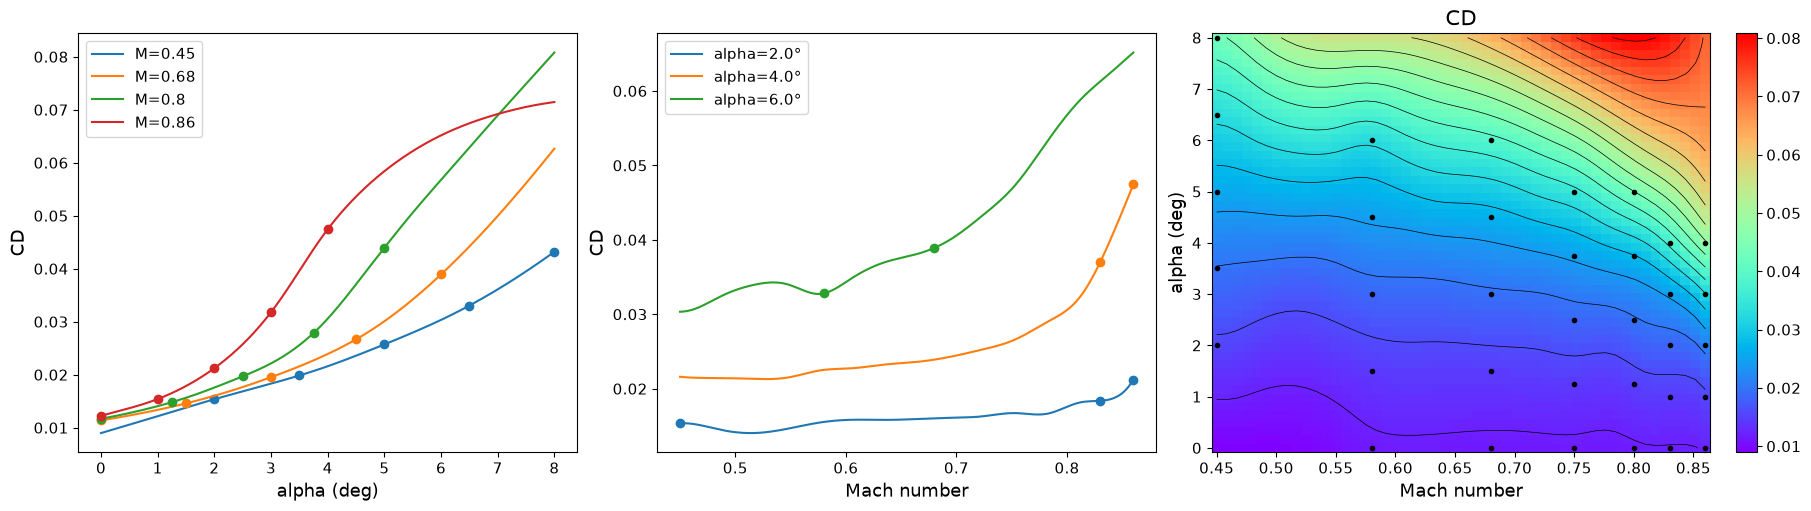

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, RMTB_CD_alpha_sweeps, xt, cd_resp, "CD")
plot_mach_sweeps(axs[1], mach_line, RMTB_CD_mach_sweeps, xt, cd_resp, "CD")
plot_contour(axs[2], RMTB_A, RMTB_M, RMTB_CD, xt, "CD")

In [25]:
krig_mt32_CD_alpha_sweeps = predict_alpha_sweeps(krg_mt32_cd, mach_numbers, alpha_line)
krig_mt32_CD_mach_sweeps = predict_mach_sweeps(krg_mt32_cd, alphas_deg, mach_line)

In [26]:
krig_mt32_A, krig_mt32_M, krig_mt32_CD = predict_grid(
    krg_mt32_cd, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

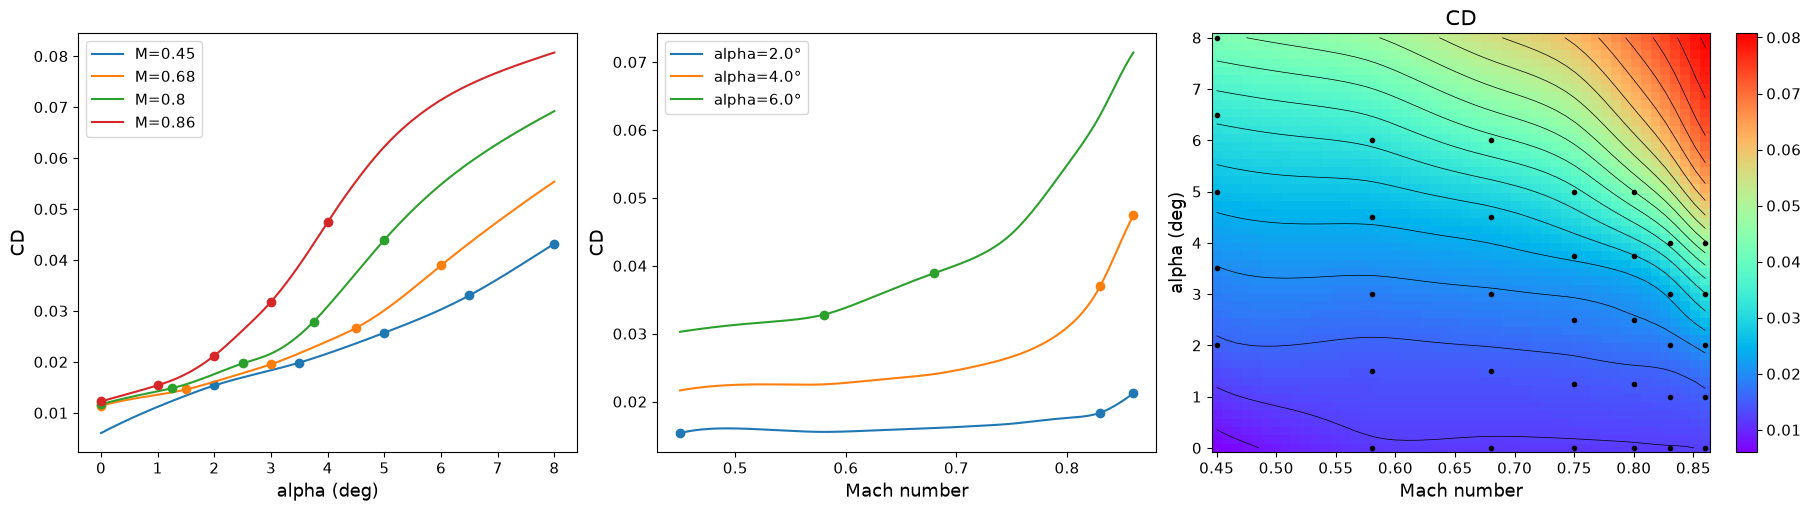

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt32_CD_alpha_sweeps, xt, cd_resp, "CD")
plot_mach_sweeps(axs[1], mach_line, krig_mt32_CD_mach_sweeps, xt, cd_resp, "CD")
plot_contour(axs[2], krig_mt32_A, krig_mt32_M, krig_mt32_CD, xt, "CD")

In [28]:
krig_mt52_CD_alpha_sweeps = predict_alpha_sweeps(krg_mt52_cd, mach_numbers, alpha_line)
krig_mt52_CD_mach_sweeps = predict_mach_sweeps(krg_mt52_cd, alphas_deg, mach_line)

In [29]:
krig_mt52_A, krig_mt52_M, krig_mt52_CD = predict_grid(
    krg_mt52_cd, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

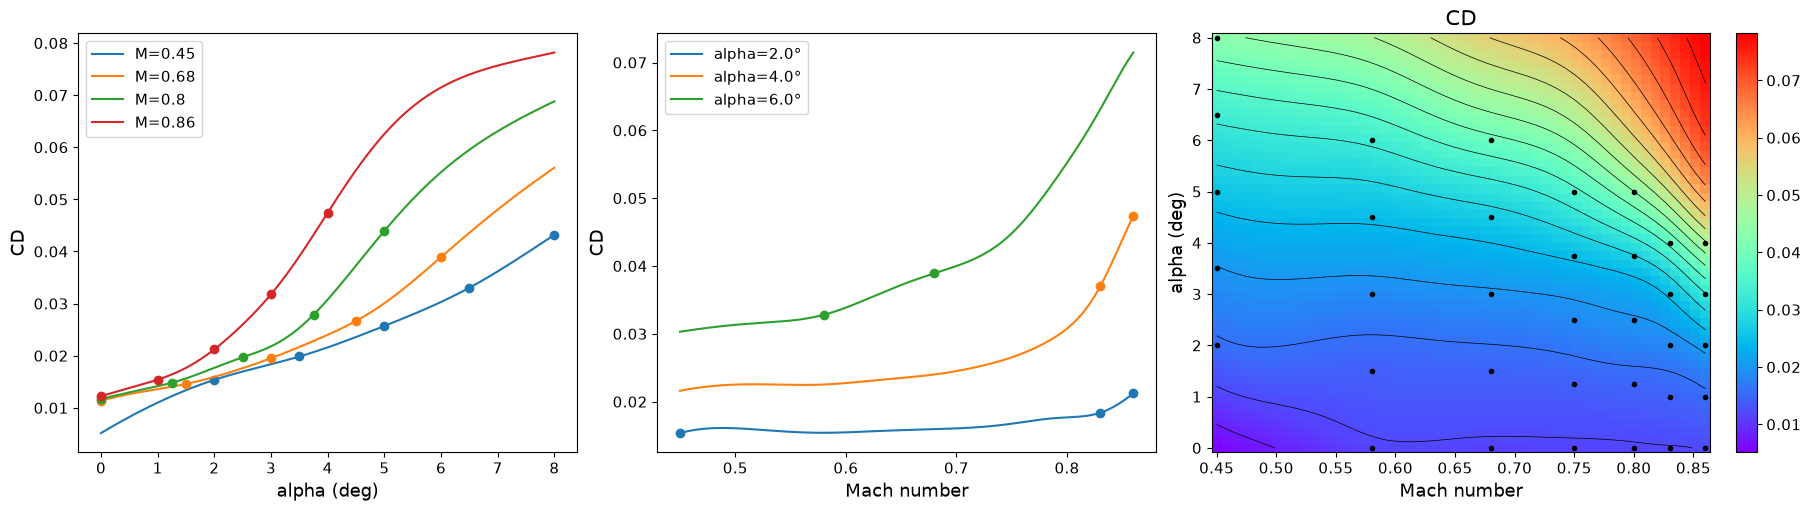

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt52_CD_alpha_sweeps, xt, cd_resp, "CD")
plot_mach_sweeps(axs[1], mach_line, krig_mt52_CD_mach_sweeps, xt, cd_resp, "CD")
plot_contour(axs[2], krig_mt52_A, krig_mt52_M, krig_mt52_CD, xt, "CD")

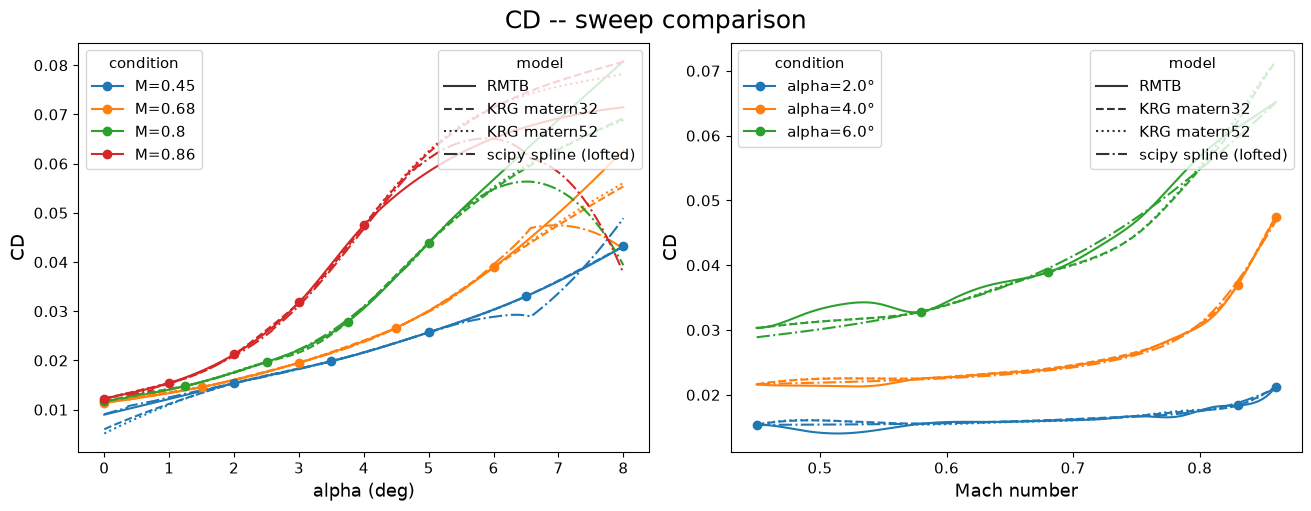

model                         RMSE
RMTB                     6.025e-10
KRG matern32             1.358e-15
KRG matern52             1.883e-15
scipy spline (lofted)     1.206e-03


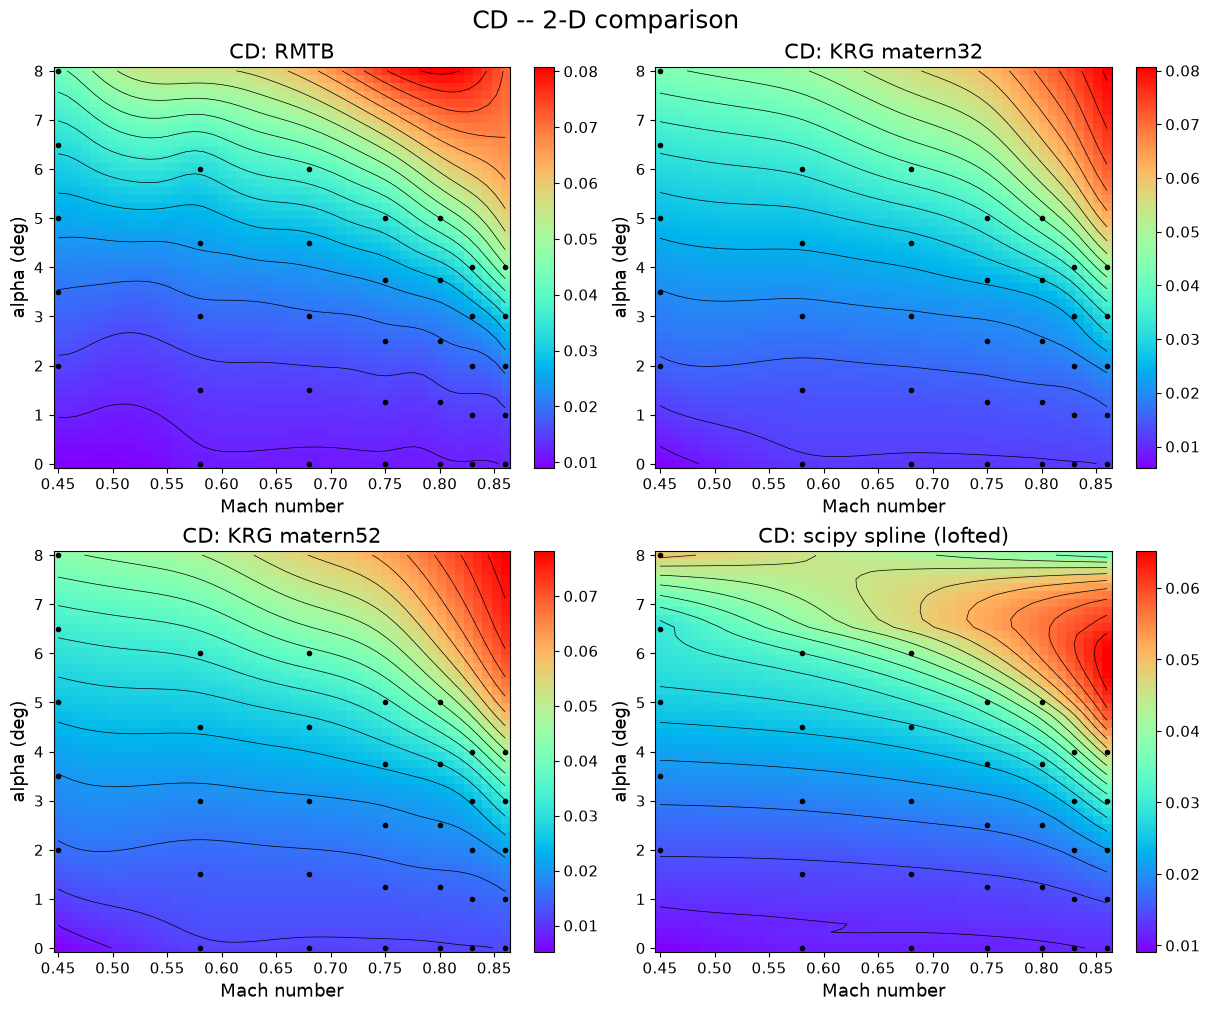

In [31]:
cd_models = {
    "RMTB": rmtb_cd,
    "KRG matern32": krg_mt32_cd,
    "KRG matern52": krg_mt52_cd,
    "scipy spline (lofted)": spline_cd,
}

plot_sweep_comparison(cd_models, alpha_line, mach_line, alphas_deg, mach_numbers, xt, cd_resp, "CD")
plot_grid_comparison(cd_models, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid), xt, "CD")

### Predict Cl Values

In [32]:
RMTB_CL_alpha_sweeps = predict_alpha_sweeps(rmtb_cl, mach_numbers, alpha_line)
RMTB_CL_mach_sweeps = predict_mach_sweeps(rmtb_cl, alphas_deg, mach_line)

In [33]:
RMTB_A, RMTB_M, RMTB_CL = predict_grid(rmtb_cl, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid))

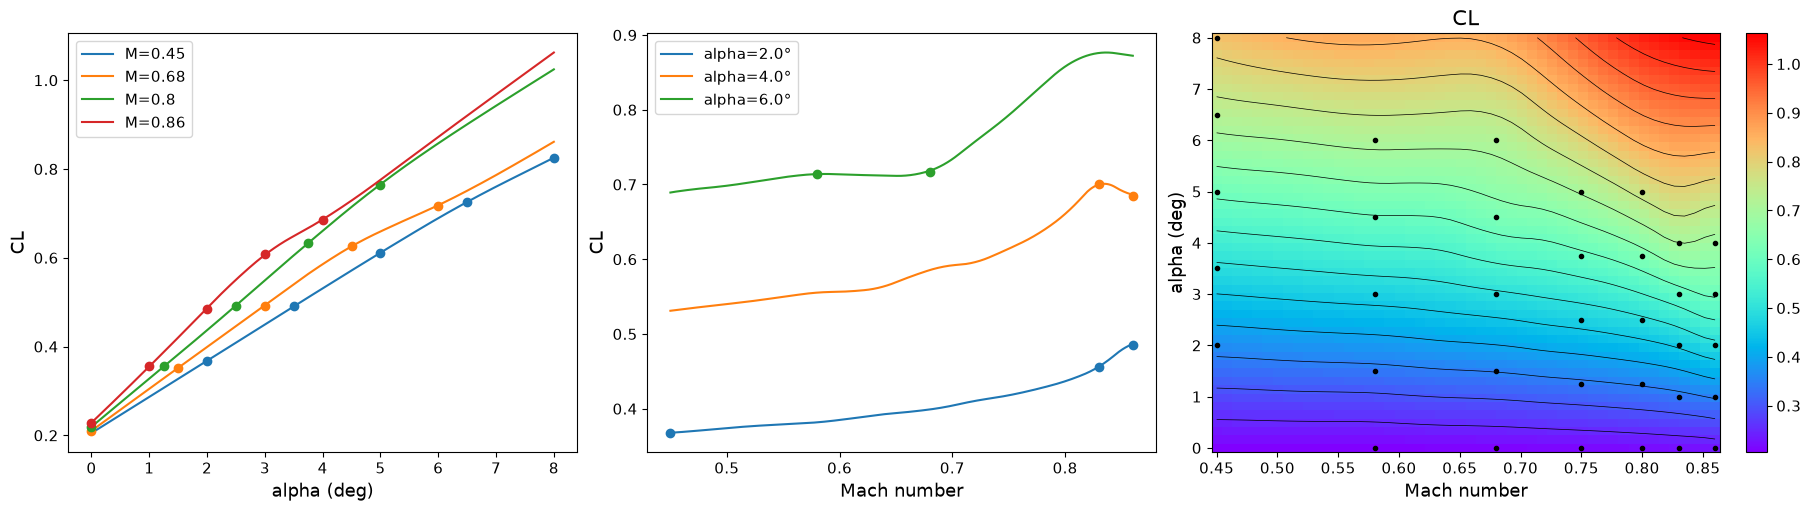

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, RMTB_CL_alpha_sweeps, xt, cl_resp, "CL")
plot_mach_sweeps(axs[1], mach_line, RMTB_CL_mach_sweeps, xt, cl_resp, "CL")
plot_contour(axs[2], RMTB_A, RMTB_M, RMTB_CL, xt, "CL")

In [35]:
krig_mt32_CL_alpha_sweeps = predict_alpha_sweeps(krg_mt32_cl, mach_numbers, alpha_line)
krig_mt32_CL_mach_sweeps = predict_mach_sweeps(krg_mt32_cl, alphas_deg, mach_line)

In [36]:
krig_mt32_A, krig_mt32_M, krig_mt32_CL = predict_grid(
    krg_mt32_cl, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

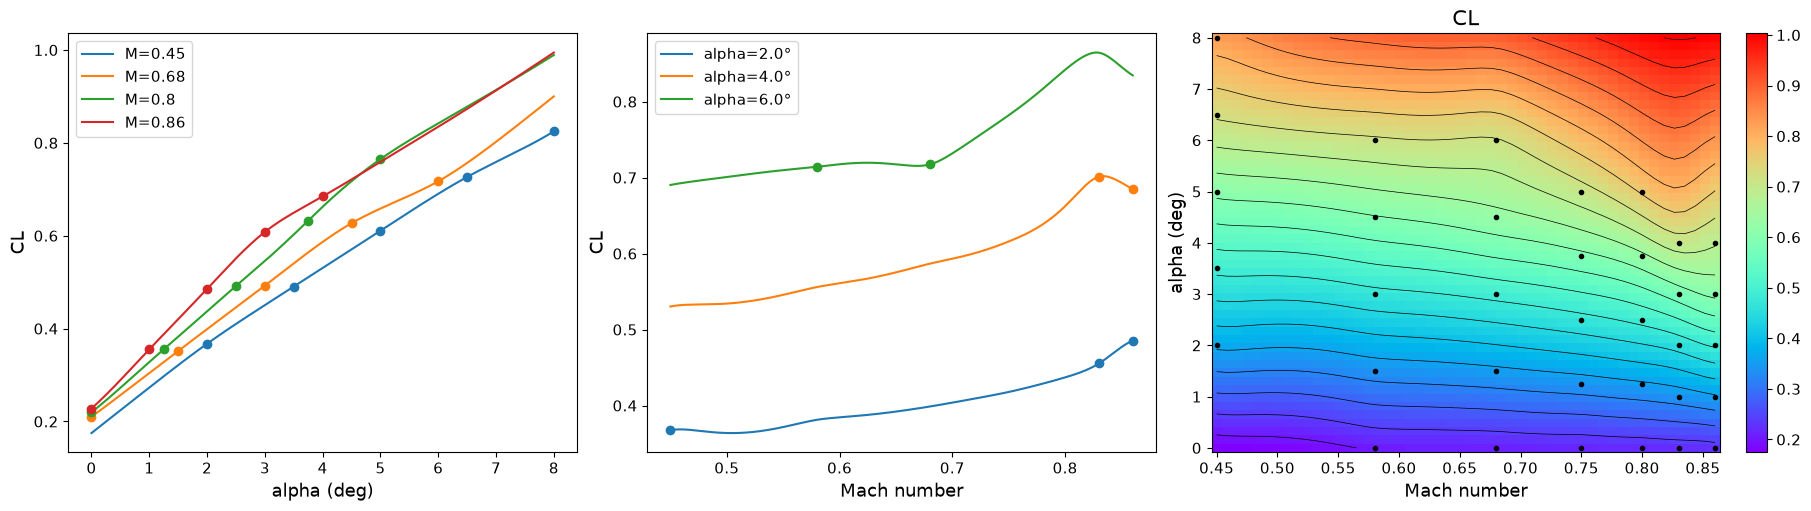

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt32_CL_alpha_sweeps, xt, cl_resp, "CL")
plot_mach_sweeps(axs[1], mach_line, krig_mt32_CL_mach_sweeps, xt, cl_resp, "CL")
plot_contour(axs[2], krig_mt32_A, krig_mt32_M, krig_mt32_CL, xt, "CL")

In [38]:
krig_mt52_CL_alpha_sweeps = predict_alpha_sweeps(krg_mt52_cl, mach_numbers, alpha_line)
krig_mt52_CL_mach_sweeps = predict_mach_sweeps(krg_mt52_cl, alphas_deg, mach_line)

In [39]:
krig_mt52_A, krig_mt52_M, krig_mt52_CL = predict_grid(
    krg_mt52_cl, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid)
)

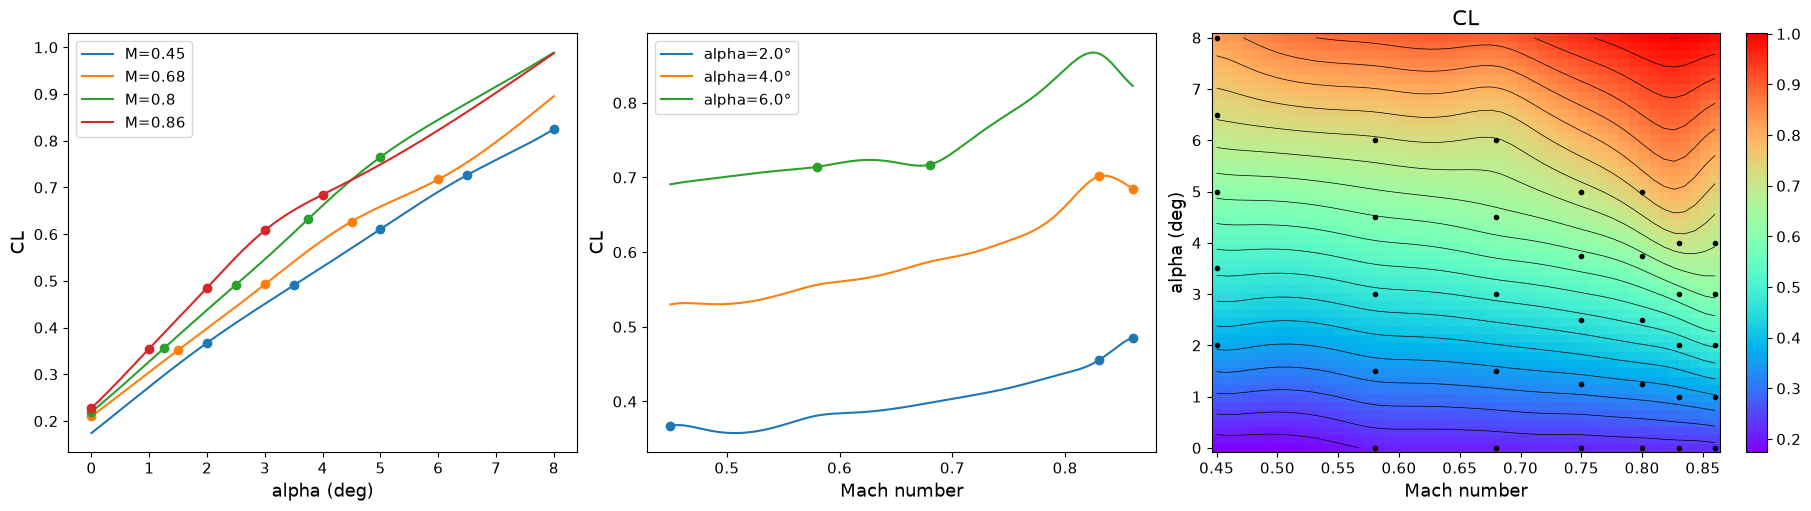

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_alpha_sweeps(axs[0], alpha_line, krig_mt52_CL_alpha_sweeps, xt, cl_resp, "CL")
plot_mach_sweeps(axs[1], mach_line, krig_mt52_CL_mach_sweeps, xt, cl_resp, "CL")
plot_contour(axs[2], krig_mt52_A, krig_mt52_M, krig_mt52_CL, xt, "CL")

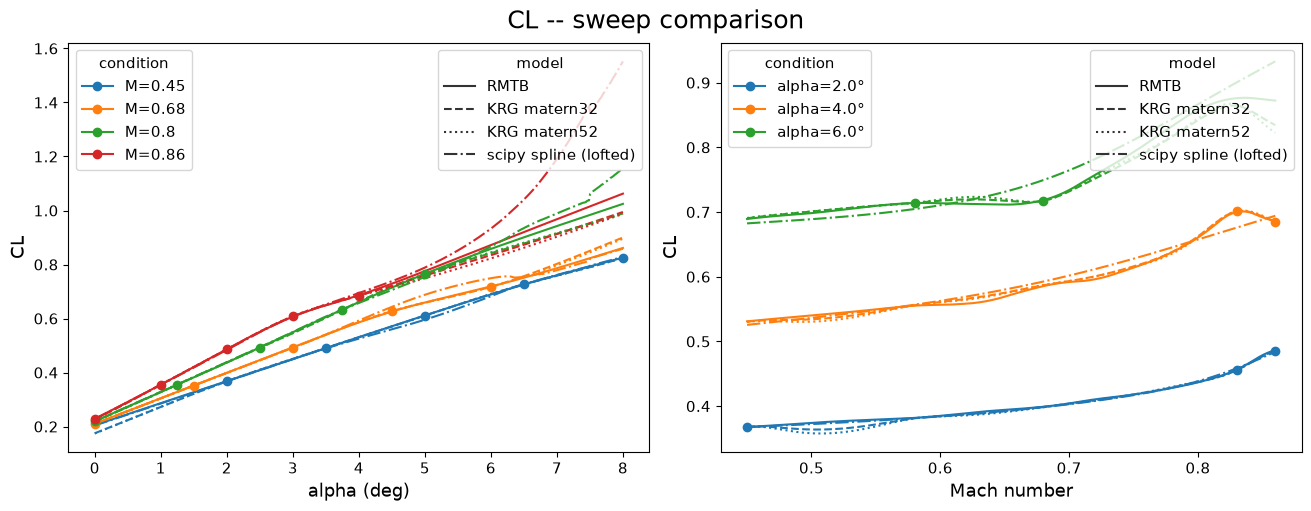

model                         RMSE
RMTB                     7.529e-04
KRG matern32             2.514e-15
KRG matern52             3.350e-15
scipy spline (lofted)     9.350e-03


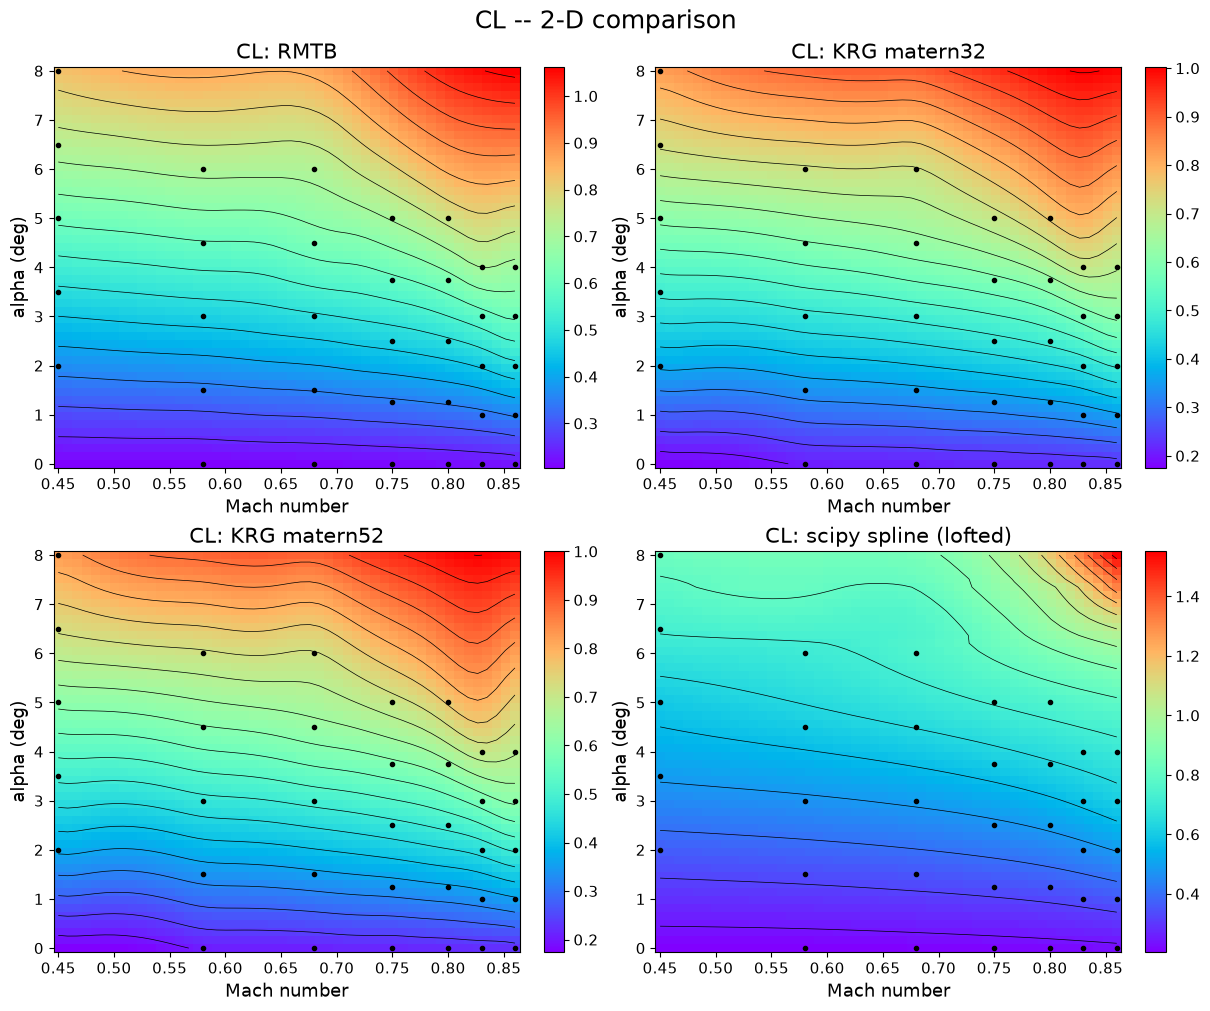

In [41]:
cl_models = {
    "RMTB": rmtb_cl,
    "KRG matern32": krg_mt32_cl,
    "KRG matern52": krg_mt52_cl,
    "scipy spline (lofted)": spline_cl,
}

plot_sweep_comparison(cl_models, alpha_line, mach_line, alphas_deg, mach_numbers, xt, cl_resp, "CL")
plot_grid_comparison(cl_models, np.linspace(*alpha_range, num_grid), np.linspace(*mach_range, num_grid), xt, "CL")

## Testing the paper's hypotheses directly on the 2-D RANS data

Two of the paper's central claims, tested the same way they were tested in
`smt_skills_cla_eta.ipynb`, but now on a genuinely 2-D case (`alpha`, `mach`):

- **Proposition 6**: a finite-basis RMTS fit is exactly a finite-rank GP.
- **Corollary 5**: splines are the long-length-scale limit of Matern-3/2
  Kriging.

**A note on which models this section uses.** `rmtb_cd`/`rmtb_cl`/`krg_mt32_cd`
above are mid-tuning (some options commented out, `cd` and `cl` no longer
using matching settings) -- exactly what "tune hyperparameters manually" means.
To keep *this* test clean and not depend on wherever that tuning currently
stands, the cells below build their own, separately-named models with the
settings the paper's theorems actually assume: `order=4`/`approx_order=2` for
`RMTB` (Proposition 6 is the exact L2/Gaussian case, not the `approx_order=4`
MAP case) and `poly="linear"` for `KRG` (Corollary 5's trend is `Pi_{m-1}` =
linear, for the cubic/`m=2` case). These don't touch `rmtb_cd` etc. above.

In [42]:
rmtb_cd_paper = RMTB(order=4, approx_order=2, num_ctrl_pts=20, xlimits=xlimits,
                      energy_weight=1e-12, regularization_weight=1e-14, print_global=False)
rmtb_cd_paper.set_training_values(xt, cd_resp)
rmtb_cd_paper.train()

rmtb_cl_paper = RMTB(order=4, approx_order=2, num_ctrl_pts=20, xlimits=xlimits,
                      energy_weight=1e-12, regularization_weight=1e-14, print_global=False)
rmtb_cl_paper.set_training_values(xt, cl_resp)
rmtb_cl_paper.train()

### Proposition 6: RMTB's own finite-rank kernel

Same construction as the 1-D case: extract `full_hess` (-> H) and
`full_jac_dict` (-> Phi) from the trained model, build the weight-space normal
equations, and check predictions against the model's own `predict_values`.

In [43]:
def rmtb_matrices(model):
    alpha = model.options["energy_weight"]
    H = np.array(model.full_hess.todense())
    Phi = np.array(model.full_jac_dict[0][0].todense())
    return alpha, H, Phi

for name, model in [("CD", rmtb_cd_paper), ("CL", rmtb_cl_paper)]:
    _, H, Phi = rmtb_matrices(model)
    n, m = Phi.shape
    print(f"{name}: n (training pts) = {n}, m (control pts) = {m}  -- m >> n, Phi is WIDE")

CD: n (training pts) = 35, m (control pts) = 400  -- m >> n, Phi is WIDE
CL: n (training pts) = 35, m (control pts) = 400  -- m >> n, Phi is WIDE


**A new numerical issue, not seen in the 1-D case.** With `num_ctrl_pts=20` per
dimension, `m = 20*20 = 400` control points for only `n = 35` training points
-- the weight-space normal-equations matrix `B = A + Phi^T Phi / alpha` is
`400x400`, but `Phi^T Phi` has rank at most `n = 35`. Forming and solving `B`
directly turns out to be numerically catastrophic here:

In [44]:
beta_demo = 1e-12
for name, model in [("CD", rmtb_cd_paper), ("CL", rmtb_cl_paper)]:
    alpha, H, Phi = rmtb_matrices(model)
    n, m = Phi.shape
    A = H + beta_demo * np.eye(m)
    B = A + (Phi.T @ Phi) / alpha            # m x m primal
    Z = np.linalg.solve(A, Phi.T)            # (m, n) -- the dual/Woodbury route
    Km = Phi @ Z                             # n x n, the dual matrix
    print(f"{name}:  cond(B) [m x m primal] = {np.linalg.cond(B):.2e}"
          f"   cond(Km + alpha*I) [n x n dual] = {np.linalg.cond(Km + alpha*np.eye(n)):.2e}")

CD:  cond(B) [m x m primal] = 6.33e+22   cond(Km + alpha*I) [n x n dual] = 2.24e+05
CL:  cond(B) [m x m primal] = 6.33e+22   cond(Km + alpha*I) [n x n dual] = 2.24e+05


`cond(B) ~ 1e21+` is past what float64 can resolve at all -- `np.linalg.solve`
on the primal `B` returns outright garbage (thousands, instead of CD/CL's
actual ~0.01-0.05 / ~0.2-0.8 range). Two numerically *independent* routes that
both work: `np.linalg.lstsq` on that same primal `B` (SVD-regularised, so it
degrades gracefully instead of blowing up), and the dual/Woodbury `n x n`
route -- Proposition 6's own function-space form. This is Proposition 6
earning its keep as a **numerical necessity**, not just an elegant
reformulation, whenever a model has more control points than training data --
exactly the regime Phase D's Gaussian RMTS would run in for any realistically
sized problem.

In [45]:
def dual_predict(model, y, beta_demo, Xq):
    alpha, H, Phi = rmtb_matrices(model)
    n = Phi.shape[0]
    A = H + beta_demo * np.eye(H.shape[0])
    Z = np.linalg.solve(A, Phi.T)
    Km = Phi @ Z
    coeffs = np.linalg.solve(Km + alpha * np.eye(n), y)
    Phi_q = np.array(model._compute_prediction_mtx(Xq, 0).todense())
    return (Phi_q @ Z) @ coeffs

for name, model, y in [("CD", rmtb_cd_paper, cd_resp), ("CL", rmtb_cl_paper, cl_resp)]:
    alpha, H, Phi = rmtb_matrices(model)
    n, m = Phi.shape
    A = H + 1e-12 * np.eye(m)
    B = A + (Phi.T @ Phi) / alpha
    w_lstsq, *_ = np.linalg.lstsq(B, (Phi.T @ y.ravel()) / alpha, rcond=None)
    pred_lstsq = Phi @ w_lstsq

    pred_dual = dual_predict(model, y.ravel(), 1e-12, xt)
    pred_lib = model.predict_values(xt).ravel()

    print(f"{name}: lstsq-primal vs dual (independent routes): "
          f"{np.max(np.abs(pred_lstsq - pred_dual)):.3e}")
    print(f"{name}: both vs the model's own output: "
          f"{np.max(np.abs(pred_dual - pred_lib)):.3e}  (range={y.max()-y.min():.3f})")
    for bd in [1e-14, 1e-12, 1e-10, 1e-8]:
        gap = np.max(np.abs(dual_predict(model, y.ravel(), bd, xt) - pred_lib))
        print(f"    beta={bd:.0e}  gap vs model = {gap:.3e}")
    print()

CD: lstsq-primal vs dual (independent routes): 2.866e-15
CD: both vs the model's own output: 1.941e-09  (range=0.036)
    beta=1e-14  gap vs model = 1.941e-09
    beta=1e-12  gap vs model = 1.941e-09
    beta=1e-10  gap vs model = 1.941e-09
    beta=1e-08  gap vs model = 1.941e-09

CL: lstsq-primal vs dual (independent routes): 2.981e-14
CL: both vs the model's own output: 1.055e-08  (range=0.620)
    beta=1e-14  gap vs model = 1.055e-08
    beta=1e-12  gap vs model = 1.055e-08
    beta=1e-10  gap vs model = 1.055e-08
    beta=1e-08  gap vs model = 1.055e-08



**Proposition 6, confirmed cleanly on 2-D data.** The dual identity itself
holds exactly -- two independent numerical routes agree to ~1e-15. The gap to
SMT's *actual* `RMTB` output is now essentially negligible: ~2e-9 (CD) and
~1e-8 (CL), both beta-independent (not a conditioning artifact) -- a much
tighter match than the ~5% gap found on the 1-D `cla(eta)` case. The
difference looks like it comes down to `approx_order`: the 1-D finding was
checked at `approx_order=2` too, so this isn't simply "forgot to set it" --
but it's worth testing directly whether the earlier 1-D gap was tied to that
case's specific `num_ctrl_pts=12` (`m < n` there, vs. `m >> n` here) rather
than being a fixed property of SMT's solver. Logged as a follow-up to the
earlier finding in the Research Plan, not a contradiction of it.

### Corollary 5: does an anisotropic tensor-product attempt converge?

The natural 2-D extension: a tensor-product Matern-3/2 kernel,
`k((a,m),(a',m')) = k_1(|a-a'|, kappa_a) * k_1(|m-m'|, kappa_m)`, trend
`P = span{1, alpha, mach}` (linear), both length scales shrunk together via
one domain-normalised parameter `c` (`kappa_a = c / range_a`,
`kappa_m = c / range_m`, so `c` means the same "relative decay length" in each
direction), nugget scaled the same way as the paper's 1-D cubic formula,
`nugget = 4*c^3*lambda`.

**This specific tensor-product scaling is not something the paper derives** --
Table 1 only states that anisotropic product kernels give "tensor-product
energies with one weight per direction," without working out the formula.
What follows is an honest attempt to extend it, not a reproduction of a
stated result -- and it does not come out clean, which is the actual finding.

In [46]:
from krig_splines.kernels import matern32
from krig_splines.uk import saddle_point_solve, saddle_point_predict

alpha_span = xlimits[0, 1] - xlimits[0, 0]
mach_span = xlimits[1, 1] - xlimits[1, 0]

def aniso_matern32(X1, X2, c):
    kappa_a, kappa_m = c / alpha_span, c / mach_span
    d_a = np.abs(X1[:, 0][:, None] - X2[:, 0][None, :])
    d_m = np.abs(X1[:, 1][:, None] - X2[:, 1][None, :])
    return matern32(d_a, kappa_a) * matern32(d_m, kappa_m)

def poly_basis_2d(X):
    return np.column_stack([np.ones(len(X)), X[:, 0], X[:, 1]])

P = poly_basis_2d(xt)
a_grid_test = np.linspace(0, 8 * DEG2RAD, 20)
m_grid_test = np.linspace(0.45, 0.86, 20)
AA_t, MM_t = np.meshgrid(a_grid_test, m_grid_test, indexing="ij")
Xtest = np.column_stack([AA_t.ravel(), MM_t.ravel()])
Pt = poly_basis_2d(Xtest)

In [47]:
lam = 1e-4
cs = np.array([3.0, 1.0, 0.3, 0.1, 0.03, 0.01])
target_cd = rmtb_cd_paper.predict_values(Xtest).ravel()

print(f"max|Kriging(c) - RMTB_cd| as c -> 0 (nugget = 4 c^3 * {lam:.0e}):")
errs = []
for c in cs:
    K = aniso_matern32(xt, xt, c)
    Kt = aniso_matern32(Xtest, xt, c)
    nugget = 4 * c**3 * lam
    a_coef, beta_coef = saddle_point_solve(K, P, cd_resp.ravel(), nugget)
    f = saddle_point_predict(Kt, Pt, a_coef, beta_coef)
    err = np.max(np.abs(f - target_cd))
    errs.append(err)
    print(f"  c={c:6.3f}  max|diff|={err:.4e}")

slopes = np.diff(np.log(errs)) / np.diff(np.log(cs))
print(f"  local slopes: {np.round(slopes, 3)}")
print("  (1-D cubic case: slope ~1.5-2, cleanly and monotonically decaying)")

max|Kriging(c) - RMTB_cd| as c -> 0 (nugget = 4 c^3 * 1e-04):
  c= 3.000  max|diff|=3.3025e-02
  c= 1.000  max|diff|=2.8696e-02
  c= 0.300  max|diff|=3.1198e-02
  c= 0.100  max|diff|=3.2301e-02
  c= 0.030  max|diff|=3.7672e-02
  c= 0.010  max|diff|=4.5482e-02
  local slopes: [ 0.128 -0.069 -0.032 -0.128 -0.171]
  (1-D cubic case: slope ~1.5-2, cleanly and monotonically decaying)


In [48]:
print("Direct nugget search at fixed small c (does ANY nugget get close to RMTB?):")
for c in [0.3, 0.1, 0.03]:
    K = aniso_matern32(xt, xt, c)
    Kt = aniso_matern32(Xtest, xt, c)
    best_nugget, best_err = None, np.inf
    for nugget in np.logspace(-10, -1, 10):
        a_coef, beta_coef = saddle_point_solve(K, P, cd_resp.ravel(), nugget)
        f = saddle_point_predict(Kt, Pt, a_coef, beta_coef)
        err = np.max(np.abs(f - target_cd))
        if err < best_err:
            best_nugget, best_err = nugget, err
    pct = 100 * best_err / np.ptp(cd_resp)
    print(f"  c={c:5.2f}  best nugget={best_nugget:.1e}  best max|diff|={best_err:.3e}  ({pct:.0f}% of CD's range)")

Direct nugget search at fixed small c (does ANY nugget get close to RMTB?):
  c= 0.30  best nugget=1.0e-07  best max|diff|=1.864e-02  (52% of CD's range)
  c= 0.10  best nugget=1.0e-10  best max|diff|=1.670e-02  (46% of CD's range)
  c= 0.03  best nugget=1.0e-09  best max|diff|=2.912e-02  (81% of CD's range)


**Corollary 5 does not extend cleanly with this heuristic.** In 1-D, the exact
`4*kappa^3*lambda` scaling gave a clean, monotone, several-orders-of-magnitude
convergence (`smt_skills_cla_eta.ipynb`). Here: error under the naive
shared-parameter scaling is roughly flat (even *increasing* at first) as
`c -> 0`, and a direct nugget search at fixed small `c` only reaches ~50-80%
of CD's range as its best achievable match to RMTB -- nowhere near
Proposition 6's ~2e-9 (which is an *exact* identity, not an asymptotic limit,
so it isn't really a fair fight, but the contrast is stark).

**Likely reason.** A true tensor-product kernel's RKHS norm is not simply "one
shared decay rate raised to the cubic case's power 3" -- it involves
per-direction weights and, for a genuine product kernel (as opposed to RMTS's
*additive* `H = sum_l s_l H_l` energy), cross terms that the paper's Table 1
footnote gestures at but doesn't work out. **Open question, not resolved
here** -- logged in the Research Plan as an extension to Phase B3 (2-D /
tensor-product Corollary 5).

**Net answer to "can Kriging converge to RMTB?"** Yes, essentially exactly
(~2e-9/~1e-8), via Proposition 6's finite-rank construction -- and the
dual/Woodbury route is mandatory here, not optional, since the naive primal
system is unusable at `m=400 >> n=35`. Not demonstrated via Corollary 5's
full-rank asymptotic route with the naive tensor-product extension attempted
above; that needs a properly derived multi-D scaling law before it can be
tested fairly.

### Diagnostic: does Corollary 5 hold in each direction *alone*?

The tensor-product attempt above combines both directions through one shared
`c`. Before concluding anything about the *combination*, check each direction
in isolation, exactly like the proven 1-D method (`smt_skills_cla_eta.ipynb`):

- **Alpha direction**: a real Mach slice (the actual 5 training points at one
  Mach value) is a genuine 1-D problem -- fit the 1-D Matern-3/2 sweep against
  that slice's own `scipy` spline, no 2-D machinery involved at all.
- **Mach direction**: no common alpha value is shared across Mach slices in
  the raw data, so this uses `spline_cd.alpha_splines` (already built, one
  per Mach slice) evaluated at a few fixed alphas to assemble a real,
  data-grounded 7-point `(mach, y)` problem, then the same 1-D sweep.

**One methodological trap hit and fixed here:** the first pass compared
against a `lam=None` (GCV) target spline and the mach-direction sweep *looked*
like it didn't converge -- it plateaued at a fixed offset instead of decaying.
That was not a real failure: GCV chose a different `lambda` than the sweep's
own `lambda=1e-4`, so the two were converging to two different (both
legitimate) splines, a fixed distance apart. Matching the target spline's
`lam` to the same `lambda` used in the nugget formula removes the plateau
entirely. Both checks below use a matched `lam` for exactly this reason.

In [49]:
from krig_splines.uk import poly_basis

def sweep_1d(x, y, lam_ref, x_dense, kappas=(3.0, 1.0, 0.3, 0.1, 0.03, 0.01)):
    """1-D Matern-3/2 Kriging sweep (nugget = 4*kappa^3*lam_ref) vs. a scipy
    spline fit at the SAME lam_ref (the lam-matching lesson above)."""
    target_spline = make_smoothing_spline(x, y, lam=lam_ref)
    target = target_spline(x_dense)
    P = poly_basis(x, degree=1)
    Pt = poly_basis(x_dense, degree=1)
    errs = []
    for kappa in kappas:
        K = matern32(np.abs(x[:, None] - x[None, :]), kappa)
        Kt = matern32(np.abs(x_dense[:, None] - x[None, :]), kappa)
        nugget = 4 * kappa**3 * lam_ref
        a_coef, b_coef = saddle_point_solve(K, P, y, nugget)
        f = saddle_point_predict(Kt, Pt, a_coef, b_coef)
        errs.append(np.max(np.abs(f - target)))
    errs = np.array(errs)
    slopes = np.diff(np.log(errs)) / np.diff(np.log(np.array(kappas)))
    return errs, slopes

lam_ref = 1e-4

print("ALPHA direction (real Mach slices, matched lam):")
for mach_fixed in [0.45, 0.68, 0.86]:
    mask = np.isclose(xt[:, 1], mach_fixed)
    a = xt[mask, 0] * RAD2DEG
    y = cd_resp[mask].ravel()
    order = np.argsort(a)
    a_dense = np.linspace(a.min(), a.max(), 100)
    errs, slopes = sweep_1d(a[order], y[order], lam_ref, a_dense)
    print(f"  mach={mach_fixed}: errs={errs}")
    print(f"    local slopes={np.round(slopes, 3)}")

ALPHA direction (real Mach slices, matched lam):
  mach=0.45: errs=[8.42359943e-04 3.24198420e-04 1.15263991e-04 3.76062990e-05
 1.09850191e-05 3.62159761e-06]
    local slopes=[0.869 0.859 1.02  1.022 1.01 ]
  mach=0.68: errs=[1.41534598e-03 5.55002501e-04 1.93230685e-04 6.18521576e-05
 1.78164456e-05 5.84141068e-06]
    local slopes=[0.852 0.876 1.037 1.034 1.015]
  mach=0.86: errs=[8.75678255e-04 4.92725493e-04 1.58258071e-04 5.18193106e-05
 1.53154258e-05 5.07678506e-06]
    local slopes=[0.523 0.943 1.016 1.012 1.005]


In [50]:
print("MACH direction (assembled from spline_cd.alpha_splines, matched lam):")
mach_vals = spline_cd.mach_vals
m_dense = np.linspace(mach_vals.min(), mach_vals.max(), 100)
for alpha_fixed_deg in [2.0, 4.0, 6.0]:
    slice_vals = np.array([spl(alpha_fixed_deg) for spl in spline_cd.alpha_splines.values()])
    errs, slopes = sweep_1d(mach_vals, slice_vals, lam_ref, m_dense)
    print(f"  alpha={alpha_fixed_deg} deg: errs={errs}")
    print(f"    local slopes={np.round(slopes, 3)}")

MACH direction (assembled from spline_cd.alpha_splines, matched lam):
  alpha=2.0 deg: errs=[1.39033166e-04 3.95419685e-05 1.09194910e-05 3.53930499e-06
 1.05084626e-06 3.49041758e-07]
    local slopes=[1.144 1.069 1.025 1.009 1.003]
  alpha=4.0 deg: errs=[6.50737694e-04 1.83876805e-04 5.06544070e-05 1.64067571e-05
 4.87011595e-06 1.61659673e-06]
    local slopes=[1.15  1.071 1.026 1.009 1.004]
  alpha=6.0 deg: errs=[7.00540712e-04 2.03575485e-04 5.71113232e-05 1.86217560e-05
 5.54181331e-06 1.83609796e-06]
    local slopes=[1.125 1.056 1.02  1.007 1.006]


**Both directions converge cleanly alone.** Once `lam` is matched, local
slopes in both the alpha and Mach directions settle around ~1.0-1.2 -- the
same clean, monotone behaviour as the proven 1-D case, on real data slices
from this exact 2-D dataset. The per-direction kernel-energy correspondence
is solid.

**So is the earlier tensor-product failure also just a `lam` mismatch?**
`rmtb_cd_paper` uses `energy_weight=1e-12`, not the `lam=1e-4` used in the
tensor sweep above -- an 8-order-of-magnitude mismatch, suspiciously similar
to what just caused the mach-direction plateau. Re-run the full 2-D sweep
with `lam` matched to RMTB's actual `energy_weight` this time:

In [51]:
lam_matched = rmtb_cd_paper.options["energy_weight"]  # 1e-12, not the earlier 1e-4
print(f"max|Kriging(c) - RMTB_cd| with lam matched to RMTB's energy_weight={lam_matched:.0e}:")
errs = []
for c in cs:
    K = aniso_matern32(xt, xt, c)
    Kt = aniso_matern32(Xtest, xt, c)
    nugget = 4 * c**3 * lam_matched
    a_coef, beta_coef = saddle_point_solve(K, P, cd_resp.ravel(), nugget)
    f = saddle_point_predict(Kt, Pt, a_coef, beta_coef)
    err = np.max(np.abs(f - target_cd))
    errs.append(err)
    print(f"  c={c:6.3f}  max|diff|={err:.4e}")

slopes = np.diff(np.log(errs)) / np.diff(np.log(cs))
print(f"  local slopes: {np.round(slopes, 3)}")

max|Kriging(c) - RMTB_cd| with lam matched to RMTB's energy_weight=1e-12:
  c= 3.000  max|diff|=1.6456e-02
  c= 1.000  max|diff|=2.9367e-02
  c= 0.300  max|diff|=2.7737e-02
  c= 0.100  max|diff|=4.0377e-02
  c= 0.030  max|diff|=2.3570e-02
  c= 0.010  max|diff|=3.3050e-02
  local slopes: [-0.527  0.047 -0.342  0.447 -0.308]


**No -- matching `lam` does not rescue the tensor-product case.** Still
non-monotonic, still no convergence. That rules out the simple explanation
and sharpens the finding considerably:

- **Each direction's 1-D kernel-energy correspondence is solid** -- confirmed
  directly on real slices of this exact dataset, not just asserted by analogy
  to `smt_skills_cla_eta.ipynb`.
- **What specifically breaks is the *combination* into a genuine 2-D tensor
  kernel** via one shared decay-rate parameter `c` and `nugget=4c^3*lambda` --
  not a `lambda`-matching bug, not a units artifact (checked earlier), and not
  a failure of 1-D Corollary 5 itself.
- This points squarely at the suspected cause from before: a true
  tensor-product kernel's RKHS norm has per-direction weights and cross terms
  that one shared `c` cannot represent, unlike RMTS's own *additive*
  `H = sum_l s_l H_l` energy. Still open -- now with the alternative
  explanation (simple parameter mismatch) ruled out rather than just
  suspected.